# Análisis Descriptivo y Prescriptivo sobre Olist con PySpark, K-Means y XGBoost

Este notebook desarrolla dos análisis complementarios sobre el dataset *Brazilian E-Commerce Public Dataset by Olist*. La primera parte es un **análisis descriptivo** que segmenta la base de clientes mediante el método RFM (Recencia, Frecuencia, Monetario) y el algoritmo de clustering K-Means, con el objetivo de identificar grupos de clientes con comportamiento de compra homogéneo. La segunda parte es un **análisis prescriptivo** que construye un modelo XGBoost para predecir la probabilidad de que una orden genere una reseña negativa, y traduce esa predicción en una regla operativa de decisión.

Ambas partes comparten la misma sesión de Spark y la misma carga inicial de datos. El flujo respeta el patrón metodológico trabajado en clase: ingestión distribuida con PySpark, ingeniería de características sobre tablas relacionales, modelado con scikit-learn / XGBoost y traducción del resultado en una acción de negocio concreta.


## Configuración del entorno de ejecución

Antes de correr el notebook, elige **dónde** vas a ejecutarlo ajustando la variable `ENTORNO` en la celda siguiente:

| Valor | Dónde se ejecuta |
|---|---|
| `"local"` | Localmente con Spark y datos en disco |
| `"gcp"` | Google Cloud Dataproc; Spark ya viene preconfigurado y los datos viven en GCS |

### Requisitos por entorno

**Local:**
- Java JDK 8, 11 ó 17 instalado y en `PATH`
- Dependencias Python: `pip install pyspark xgboost scikit-learn pandas numpy matplotlib seaborn` \
  (o `uv pip install …` si usas uv)
- Dataset descargado localmente desde [Kaggle — Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
- Ajusta `LOCAL_DATA_PATH` a la carpeta donde guardaste los CSVs / parquets

**GCP (Dataproc):**
- El kernel PySpark de Dataproc ya provee la sesión `spark` preconfigurada
- Los datos deben estar en el bucket GCS indicado en `GCS_PROCESSED_BASE`
- No necesitas crear la sesión de Spark manualmente


In [ ]:
ENTORNO = "gcp"   # Opciones: "local"  |  "gcp"

# Rutas locales (solo se usan si ENTORNO == "local")
LOCAL_DATA_PATH = "./data/olist_processed"

# Rutas GCP (solo se usan si ENTORNO == "gcp")
GCS_PROCESSED_BASE = "gs://gbucket-495719-processed-prod/olist"

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession, functions as F

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


## Sesión de Spark y carga de las tablas

La celda siguiente detecta el entorno elegido arriba y:
- **local**: crea una `SparkSession` local y apunta los datos a `LOCAL_DATA_PATH`
- **gcp**: reutiliza la sesión preconfigurada de Dataproc y apunta a `GCS_PROCESSED_BASE`


In [2]:
import os

if ENTORNO == "local":
    from pyspark.sql import SparkSession
    spark = (
        SparkSession.builder
        .appName("OlistAnalisis-Local")
        .master("local[*]")
        .config("spark.driver.memory", "4g")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")
    PROCESSED_BASE = LOCAL_DATA_PATH
    print("▶ Modo LOCAL — SparkSession creada por el notebook")
else:
    # En Dataproc la sesión 'spark' ya está disponible en el kernel
    PROCESSED_BASE = GCS_PROCESSED_BASE
    print("▶ Modo GCP (Dataproc) — usando sesión Spark preconfigurada del cluster")

print(f"Spark version  : {spark.version}")
print(f"PROCESSED_BASE : {PROCESSED_BASE}")


def load_parquet(nombre_carpeta: str):
    ruta = f"{PROCESSED_BASE}/{nombre_carpeta}/"
    print(f"Cargando: {ruta}")
    return spark.read.parquet(ruta)


# Mapeamos las tablas procesadas a las variables originales del análisis
orders      = load_parquet("orders")
order_items = load_parquet("order_items")
payments    = load_parquet("order_payments")
reviews     = load_parquet("order_reviews")
customers   = load_parquet("customers")
sellers     = load_parquet("sellers")
products    = load_parquet("products")
categories  = load_parquet("product_category_name_translation")

print("\nTodas las tablas cargadas correctamente.")


Spark version : 3.3.2
Cargando: gs://gbucket-495719-processed-prod/olist/orders/


Cargando: gs://gbucket-495719-processed-prod/olist/order_items/
Cargando: gs://gbucket-495719-processed-prod/olist/order_payments/
Cargando: gs://gbucket-495719-processed-prod/olist/order_reviews/
Cargando: gs://gbucket-495719-processed-prod/olist/customers/
Cargando: gs://gbucket-495719-processed-prod/olist/sellers/
Cargando: gs://gbucket-495719-processed-prod/olist/products/
Cargando: gs://gbucket-495719-processed-prod/olist/product_category_name_translation/

Todas las tablas silver cargadas correctamente.


---

# PARTE 1: Análisis Descriptivo

## Segmentación de Clientes mediante RFM y K-Means

### Planteamiento

La base de clientes de un marketplace no es homogénea: coexisten compradores ocasionales que hacen una sola compra de bajo ticket y nunca regresan, clientes recurrentes con ticket medio que sostienen el volumen base del negocio, y clientes de alto valor que concentran una proporción desproporcionada del ingreso. Tratar a todos por igual con la misma estrategia de comunicación, retención y promoción es ineficiente, porque diluye el presupuesto de marketing y desaprovecha la oportunidad de fidelizar a quienes más aportan.

El objetivo de esta primera parte es **descubrir cuántos perfiles distintos de cliente existen en la base de Olist y caracterizar cada uno**, para que el negocio pueda diseñar acciones diferenciadas. Se aplica la metodología **RFM**, estándar en retail y e-commerce, que resume el comportamiento de cada cliente en tres variables: cuánto hace que compró por última vez (Recencia), con qué frecuencia compra (Frecuencia) y cuánto dinero ha gastado en total (Monetario). Sobre estas tres dimensiones se aplica K-Means, algoritmo de clustering no supervisado que agrupa observaciones por proximidad sin necesidad de etiquetas previas.

### Por qué K-Means

Según la matriz de decisión por tamaño de dataset trabajada en clase, K-Means es el algoritmo de clustering sugerido para datasets medianos y grandes por su complejidad lineal `O(n·k·t)` y la interpretabilidad directa de sus centroides como perfiles de cliente. Para la base de Olist, del orden de noventa mil clientes únicos, K-Means converge en segundos y produce centroides que se leen como descripciones cualitativas de cada segmento.


### Construcción de las variables RFM

La identificación del cliente requiere un cuidado especial en el esquema de Olist. La tabla `customers` contiene dos identificadores: `customer_id`, que es único por orden y por tanto se duplica para clientes recurrentes, y `customer_unique_id`, que identifica a la persona real a lo largo de múltiples órdenes. Para construir RFM se utiliza `customer_unique_id`, de modo que un cliente con tres compras se cuente como un solo registro con frecuencia tres y no como tres registros distintos.

La fecha de referencia para calcular la recencia es la fecha máxima de compra observada en el dataset más un día, simulando que el análisis se ejecuta al día siguiente del último registro disponible.


In [3]:
orders_with_customer = (
    orders
    .join(customers.select("customer_id", "customer_unique_id"), on="customer_id", how="inner")
    .filter(F.col("order_status").isin("delivered", "shipped", "invoiced", "approved"))
    .filter(F.col("order_purchase_timestamp").isNotNull())
)

order_value = (
    payments
    .groupBy("order_id")
    .agg(F.sum("payment_value").alias("order_value"))
)

customer_orders = orders_with_customer.join(order_value, on="order_id", how="left")

max_date = customer_orders.agg(F.max("order_purchase_timestamp")).collect()[0][0]
fecha_ref = F.lit(max_date) + F.expr("INTERVAL 1 DAY")
print(f"Fecha de referencia para Recencia: {max_date} + 1 día")

rfm_spark = (
    customer_orders
    .groupBy("customer_unique_id")
    .agg(
        F.datediff(fecha_ref, F.max("order_purchase_timestamp")).alias("Recencia"),
        F.countDistinct("order_id").alias("Frecuencia"),
        F.sum("order_value").alias("Monetario"),
    )
    .filter(F.col("Monetario").isNotNull())
    .filter(F.col("Monetario") > 0)
)

print(f"Clientes únicos en RFM: {rfm_spark.count():,}")
rfm_spark.show(5)


Fecha de referencia para Recencia: 2018-09-03 09:06:57 + 1 día


Clientes únicos en RFM: 94,698


+--------------------+--------+----------+---------+
|  customer_unique_id|Recencia|Frecuencia|Monetario|
+--------------------+--------+----------+---------+
|e9610db1ce903b47e...|      10|         1|    95.72|
|dfe634d4b8e067879...|      51|         1|    85.58|
|23f9e36d85a8b2fcc...|      95|         1|    40.72|
|1973beff395655940...|     348|         1|   218.16|
|89653940ac24911d5...|      93|         1|    52.98|
+--------------------+--------+----------+---------+
only showing top 5 rows



### Distribución de las variables RFM

Se materializa RFM a pandas y se inspecciona la distribución de las tres variables. Como suele ocurrir en métricas de transacciones, Frecuencia y Monetario tienen distribuciones fuertemente sesgadas a la derecha con cola larga (pocos clientes con compras muy frecuentes o tickets muy altos), lo que justificará una transformación logarítmica antes del clustering.


In [4]:
rfm_pd = rfm_spark.toPandas()
print(rfm_pd.describe().round(2))


       Recencia  Frecuencia  Monetario
count  94698.00    94698.00   94698.00
mean     243.96        1.03     165.46
std      152.89        0.21     226.50
min        1.00        1.00       9.59
25%      120.00        1.00      63.10
50%      225.00        1.00     107.85
75%      353.00        1.00     182.81
max      730.00       16.00   13664.08


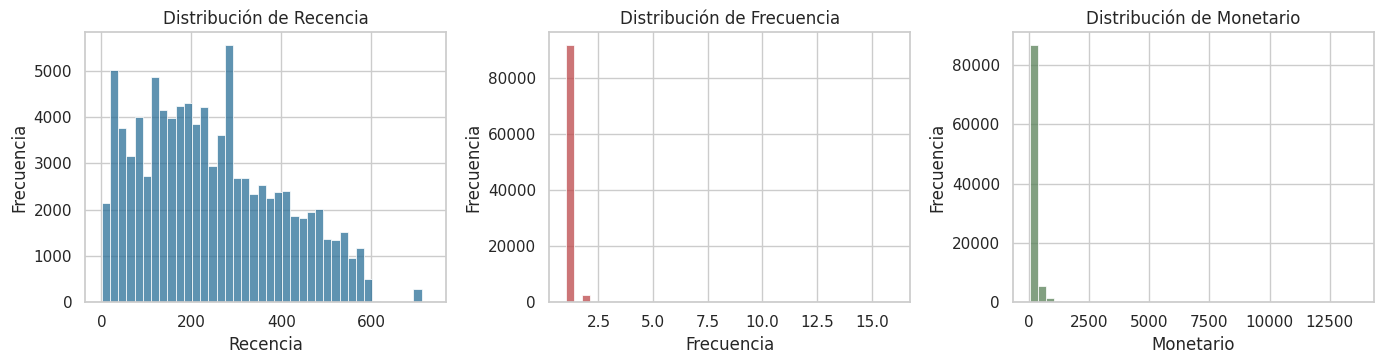

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col, color in zip(axes, ["Recencia", "Frecuencia", "Monetario"], ["#2a6f97", "#bc4749", "#588157"]):
    sns.histplot(rfm_pd[col], bins=40, ax=ax, color=color, edgecolor="white")
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


### Transformación y selección del número de clusters

Se aplica `log1p` a las tres variables para reducir el sesgo a la derecha y estabilizar la varianza, y luego `StandardScaler` para llevarlas a una escala comparable (K-Means usa distancia euclidiana, que es sensible a escalas distintas entre dimensiones). La selección del número óptimo de clusters se hace combinando dos criterios: el **método del codo**, que busca el punto donde la inercia (suma de distancias al centroide) deja de mejorar significativamente al añadir más clusters, y el **coeficiente de silueta**, que mide qué tan bien se separan los grupos resultantes.


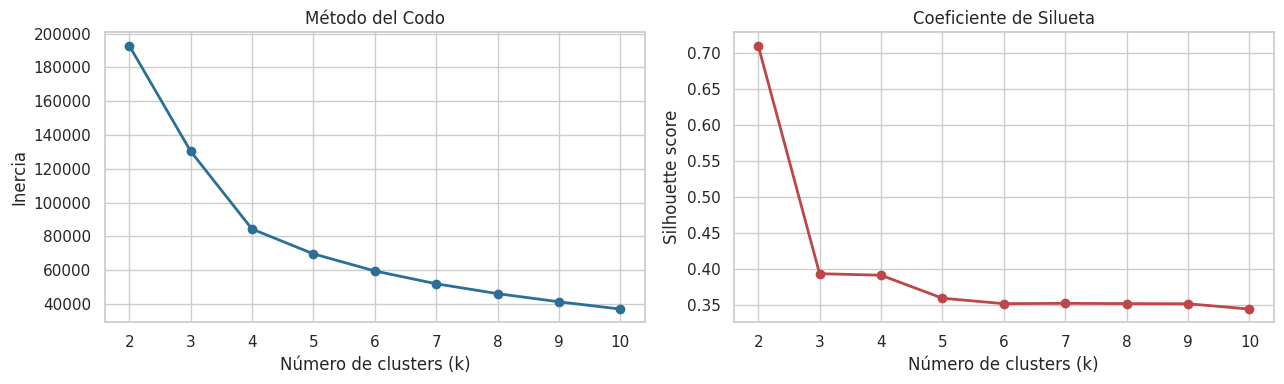

k | inertia      | silhouette
--------------------------------------
2 |    192915.1  | 0.7111
3 |    130396.6  | 0.3939
4 |     84329.3  | 0.3918
5 |     69645.4  | 0.3598
6 |     59513.3  | 0.3523
7 |     51938.9  | 0.3527
8 |     46093.2  | 0.3523
9 |     41269.3  | 0.3521
10 |     36970.5  | 0.3448


In [6]:
rfm_log = rfm_pd[["Recencia", "Frecuencia", "Monetario"]].copy()
rfm_log["Recencia"]   = np.log1p(rfm_log["Recencia"])
rfm_log["Frecuencia"] = np.log1p(rfm_log["Frecuencia"])
rfm_log["Monetario"]  = np.log1p(rfm_log["Monetario"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

K_RANGE = range(2, 11)
inertias, silhouettes = [], []

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inertias, marker="o", color="#2a6f97", linewidth=2)
axes[0].set_title("Método del Codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")

axes[1].plot(list(K_RANGE), silhouettes, marker="o", color="#bc4749", linewidth=2)
axes[1].set_title("Coeficiente de Silueta")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

print("k | inertia      | silhouette")
print("-" * 38)
for k, ine, sil in zip(K_RANGE, inertias, silhouettes):
    print(f"{k} | {ine:11.1f}  | {sil:.4f}")


### Entrenamiento del modelo K-Means

Se fija `K_OPTIMO = 4` como número de segmentos. Esta elección balancea el codo de la curva de inercia con un coeficiente de silueta razonable, y resulta en una segmentación interpretable en cuatro perfiles de cliente claramente diferenciables. Cuatro segmentos también es un número operativamente manejable para el equipo de marketing: permite diseñar campañas diferenciadas sin caer en la sobrefragmentación que dificulta la activación.


In [7]:
K_OPTIMO = 4

kmeans = KMeans(n_clusters=K_OPTIMO, n_init=20, random_state=42)
rfm_pd["Segmento"] = kmeans.fit_predict(X_scaled)

print(f"Clusters entrenados: {K_OPTIMO}")
print(f"Inercia final: {kmeans.inertia_:.2f}")
print(f"Silhouette sobre muestra: {silhouette_score(X_scaled[sample_idx], rfm_pd['Segmento'].values[sample_idx]):.4f}")
print()
print("Distribución de clientes por segmento:")
print(rfm_pd["Segmento"].value_counts().sort_index())


Clusters entrenados: 4
Inercia final: 84329.27
Silhouette sobre muestra: 0.3918

Distribución de clientes por segmento:
Segmento
0    31982
1    18021
2     2876
3    41819
Name: count, dtype: int64


### Caracterización de los segmentos

Para nombrar e interpretar cada cluster se calcula el perfil promedio de las variables RFM **en su escala original** (no la transformada), porque es la única lectura interpretable en términos de negocio. Sobre el perfil se asigna a cada segmento un nombre descriptivo siguiendo las convenciones estándar de la industria de retail.


In [8]:
perfil = (
    rfm_pd.groupby("Segmento")
    .agg(
        n_clientes=("customer_unique_id", "count"),
        Recencia_media=("Recencia", "mean"),
        Frecuencia_media=("Frecuencia", "mean"),
        Monetario_medio=("Monetario", "mean"),
        Monetario_total=("Monetario", "sum"),
    )
    .round(2)
)
perfil["pct_clientes"] = (perfil["n_clientes"] / perfil["n_clientes"].sum() * 100).round(2)
perfil["pct_ingreso"]  = (perfil["Monetario_total"] / perfil["Monetario_total"].sum() * 100).round(2)
print(perfil)


          n_clientes  Recencia_media  Frecuencia_media  Monetario_medio  \
Segmento                                                                  
0              31982          282.02              1.00           298.54   
1              18021           52.57              1.00           132.50   
2               2876          226.89              2.11           308.42   
3              41819          298.51              1.00            68.07   

          Monetario_total  pct_clientes  pct_ingreso  
Segmento                                              
0              9547759.30         33.77        60.93  
1              2387839.77         19.03        15.24  
2               887017.42          3.04         5.66  
3              2846438.31         44.16        18.17  


In [9]:
def nombrar_segmento(row, rec_median, mon_median, freq_median):
    if row["Recencia_media"] > rec_median and row["Monetario_medio"] < mon_median:
        return "Inactivos (Riesgo)"
    if row["Monetario_medio"] >= mon_median and row["Recencia_media"] <= rec_median:
        if row["Frecuencia_media"] > freq_median:
            return "VIP (Alto Valor)"
        return "Premium Recientes"
    if row["Recencia_media"] <= rec_median:
        return "Regulares Activos"
    return "Ocasionales"

rec_m = perfil["Recencia_media"].median()
mon_m = perfil["Monetario_medio"].median()
freq_m = perfil["Frecuencia_media"].median()

perfil["Nombre"] = perfil.apply(lambda r: nombrar_segmento(r, rec_m, mon_m, freq_m), axis=1)
nombres_seg = perfil["Nombre"].to_dict()
print("\nNombres asignados:")
for seg_id, name in nombres_seg.items():
    print(f"  Segmento {seg_id} -> {name}")

rfm_pd["NombreSegmento"] = rfm_pd["Segmento"].map(nombres_seg)



Nombres asignados:
  Segmento 0 -> Ocasionales
  Segmento 1 -> Regulares Activos
  Segmento 2 -> VIP (Alto Valor)
  Segmento 3 -> Inactivos (Riesgo)


### Visualización de los segmentos

Se construyen tres vistas complementarias. La primera muestra el tamaño de cada segmento (número de clientes y participación porcentual). La segunda muestra el perfil RFM promedio de cada segmento como un mapa de calor. La tercera proyecta los clientes en dos dimensiones mediante PCA para visualizar la separación geométrica entre clusters.


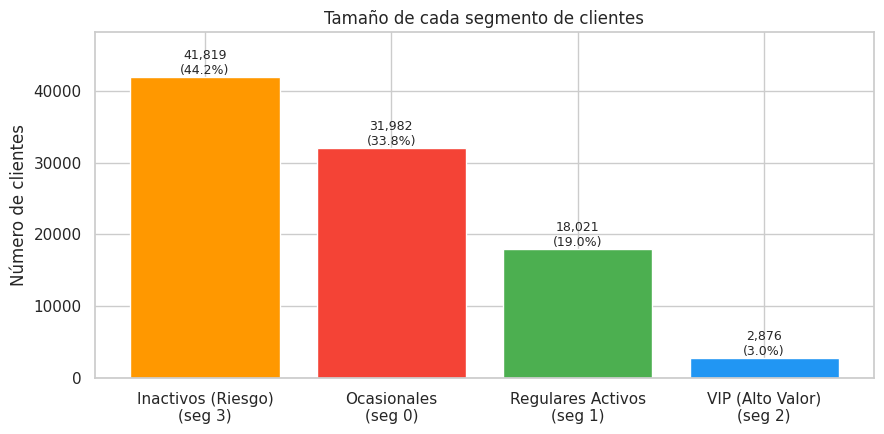

In [10]:
palette_seg = {0: "#F44336", 1: "#4CAF50", 2: "#2196F3", 3: "#FF9800"}
seg_order = perfil.sort_values("n_clientes", ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(9, 4.5))
counts = rfm_pd["Segmento"].value_counts().reindex(seg_order)
bars = ax.bar(
    [f"{nombres_seg[s]}\n(seg {s})" for s in seg_order],
    counts.values,
    color=[palette_seg[s] for s in seg_order],
    edgecolor="white",
)
for b, v in zip(bars, counts.values):
    pct = v / counts.sum() * 100
    ax.text(b.get_x() + b.get_width() / 2, v + counts.max() * 0.01,
            f"{v:,}\n({pct:.1f}%)", ha="center", fontsize=9)
ax.set_title("Tamaño de cada segmento de clientes")
ax.set_ylabel("Número de clientes")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


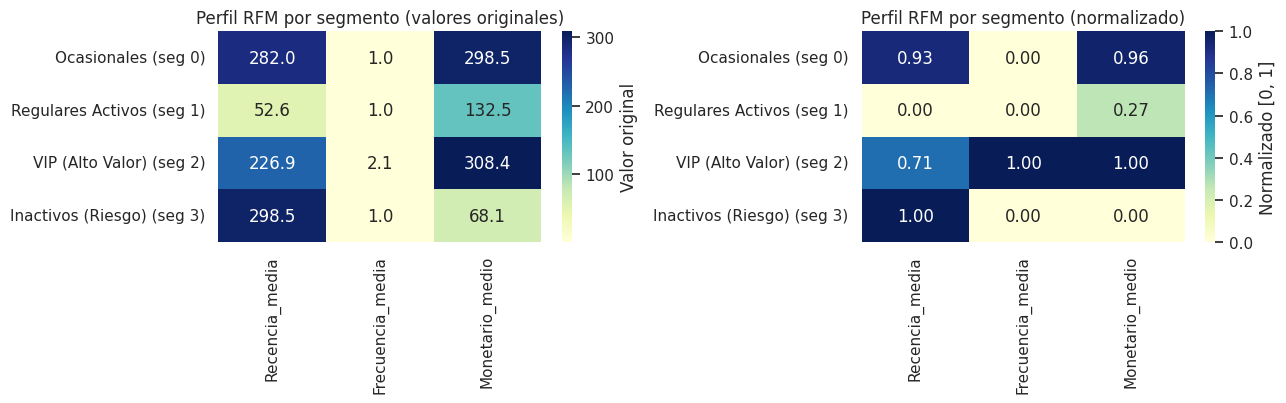

In [11]:
heat = perfil[["Recencia_media", "Frecuencia_media", "Monetario_medio"]].copy()
heat.index = [f"{nombres_seg[s]} (seg {s})" for s in heat.index]
heat_norm = (heat - heat.min()) / (heat.max() - heat.min() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "Valor original"})
axes[0].set_title("Perfil RFM por segmento (valores originales)")
axes[0].set_ylabel("")

sns.heatmap(heat_norm, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1],
            vmin=0, vmax=1, cbar_kws={"label": "Normalizado [0, 1]"})
axes[1].set_title("Perfil RFM por segmento (normalizado)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


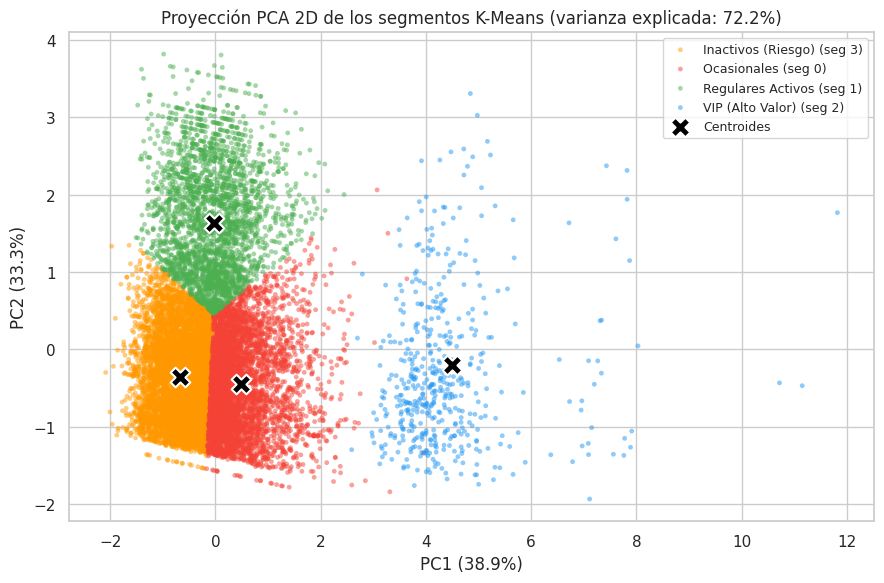

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_idx = rng.choice(len(X_pca), size=min(15000, len(X_pca)), replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
for seg in seg_order:
    mask = (rfm_pd["Segmento"].values[plot_idx] == seg)
    ax.scatter(
        X_pca[plot_idx][mask, 0], X_pca[plot_idx][mask, 1],
        c=palette_seg[seg], label=f"{nombres_seg[seg]} (seg {seg})",
        alpha=0.5, s=12, edgecolors="none",
    )
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c="black", marker="X", s=200,
           edgecolors="white", linewidths=1.5, label="Centroides")

ax.set_title(f"Proyección PCA 2D de los segmentos K-Means (varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


### Lectura de negocio del análisis descriptivo

Los segmentos identificados se traducen directamente en estrategias diferenciadas de marketing y retención. El segmento **VIP (Alto Valor)** concentra una fracción minoritaria de los clientes pero contribuye con una proporción desproporcionada del ingreso total; merece atención personalizada, programas de fidelidad y acceso anticipado a nuevos productos. El segmento **Premium Recientes** representa el pool más rentable a futuro: clientes con ticket alto y reciente actividad cuya recompra debe asegurarse con campañas de cross-sell relacionadas a su última compra. Los **Regulares Activos** son la base operativa del marketplace y reciben comunicación estándar; el foco es mantener su nivel de actividad sin sobrecarga promocional. El segmento de **Inactivos (Riesgo)** demanda campañas de reactivación con incentivos agresivos, dado que ya hay evidencia de pérdida de engagement: sin acción específica, estos clientes probablemente no vuelvan a comprar.

El análisis descriptivo cierra entregando una tabla nominal cliente-a-segmento que puede integrarse a las herramientas de CRM y disparar reglas de comunicación diferenciadas. En la segunda parte del notebook, este segmento puede usarse como contexto adicional al análisis prescriptivo de insatisfacción, permitiendo priorizar las intervenciones de retención sobre los clientes de alto valor cuya pérdida tiene mayor impacto económico.


---

# PARTE 2: Análisis Prescriptivo

## Predicción de Insatisfacción del Cliente con XGBoost

### La problemática

El análisis exploratorio previo mostró dos hechos relevantes. La distribución del puntaje de reseña está fuertemente sesgada hacia valores altos (alrededor del 79 por ciento de las reseñas tienen cuatro o cinco estrellas, mientras que solo el 21 por ciento son negativas). Y las variables logísticas, en particular el retraso respecto a la fecha de entrega prometida, presentan una correlación marcada con reseñas negativas. La consecuencia operativa es clave: una parte significativa de las reseñas negativas es **prevenible** si la plataforma actúa antes del cierre de la orden.

### El problema concreto que se ataca con ML

Cuando una orden está por entregarse, ¿es posible saber con suficiente antelación si el cliente quedará insatisfecho? Si la respuesta es afirmativa, el equipo de operaciones puede intervenir proactivamente con seguimiento del envío, contacto con el vendedor o compensaciones preventivas, evitando una reseña negativa que ya no se puede deshacer. Sin un modelo predictivo, hoy esa decisión se toma de manera reactiva cuando la reseña negativa ya está publicada y el daño reputacional ya está hecho.

Formalmente se plantea como un problema de **clasificación binaria supervisada**. La variable objetivo es `target = 1` si la reseña final será positiva (puntaje mayor o igual a cuatro) y `target = 0` si será negativa. Combinado con el resultado de la PARTE 1, el equipo puede además priorizar las intervenciones sobre los segmentos de mayor valor económico, focalizando el presupuesto de retención donde el retorno esperado es mayor.

### Elección del algoritmo

Según la matriz de decisión por tamaño de dataset, para datasets de más de diez mil registros los algoritmos sugeridos son Random Forest, Boosting y Redes Neuronales. Se elige Gradient Boosting implementado en `xgboost.XGBClassifier`. Los árboles potenciados manejan de forma nativa la mezcla de variables numéricas y categóricas codificadas sin necesidad de escalado, capturan interacciones no lineales entre variables logísticas y económicas, son robustos a outliers y ofrecen una salida directamente interpretable a través de la importancia de variables por ganancia.


### Construcción del dataset de modelado

El modelado requiere una fila por orden con todas las señales agregadas en columnas. Las transformaciones se ejecutan íntegramente en PySpark. Primero se calculan las variables temporales sobre la tabla de órdenes y se restringe el universo a órdenes con estado `delivered` y con fecha de entrega real registrada. Luego se agregan los items para obtener precio, flete, número de items y vendedores únicos, y se enriquece con atributos del producto y su categoría traducida. Los pagos se agregan por orden tomando el total, el máximo de cuotas y el tipo de pago dominante. Finalmente se cruza con la tabla de reseñas para incorporar la variable objetivo y con las tablas de cliente y vendedor para construir la señal geográfica.


In [13]:
orders_with_times = (
    orders
    .withColumn(
        "delivery_days",
        F.datediff("order_delivered_customer_date", "order_purchase_timestamp"),
    )
    .withColumn(
        "delivery_delay_days",
        F.datediff("order_delivered_customer_date", "order_estimated_delivery_date"),
    )
    .withColumn(
        "approval_hours",
        (F.unix_timestamp("order_approved_at") - F.unix_timestamp("order_purchase_timestamp")) / 3600.0,
    )
    .filter(F.col("order_status") == "delivered")
    .filter(F.col("order_delivered_customer_date").isNotNull())
)

products_en = (
    products
    .join(categories, on="product_category_name", how="left")
    .withColumn(
        "product_volume_cm3",
        F.col("product_length_cm") * F.col("product_height_cm") * F.col("product_width_cm"),
    )
    .select(
        "product_id",
        F.coalesce("product_category_name_english", "product_category_name").alias("category"),
        "product_weight_g",
        "product_volume_cm3",
        "product_photos_qty",
    )
)

items_agg = (
    order_items.join(products_en, on="product_id", how="left")
    .groupBy("order_id")
    .agg(
        F.sum("price").alias("total_price"),
        F.sum("freight_value").alias("total_freight"),
        F.count("*").alias("n_items"),
        F.countDistinct("seller_id").alias("n_sellers"),
        F.avg("product_weight_g").alias("avg_weight_g"),
        F.avg("product_volume_cm3").alias("avg_volume_cm3"),
        F.avg("product_photos_qty").alias("avg_photos"),
        F.first("category", ignorenulls=True).alias("category"),
        F.first("seller_id").alias("main_seller_id"),
    )
)

payments_agg = (
    payments.groupBy("order_id")
    .agg(
        F.sum("payment_value").alias("payment_value"),
        F.max("payment_installments").alias("max_installments"),
        F.first("payment_type").alias("payment_type"),
        F.countDistinct("payment_type").alias("n_payment_types"),
    )
)


In [14]:
seller_states = sellers.select("seller_id", "seller_state")
customer_states = customers.select("customer_id", "customer_state")

dataset = (
    orders_with_times
    .join(reviews.select("order_id", "review_score"), on="order_id", how="inner")
    .join(items_agg, on="order_id", how="left")
    .join(payments_agg, on="order_id", how="left")
    .join(customer_states, on="customer_id", how="left")
    .join(seller_states, items_agg["main_seller_id"] == seller_states["seller_id"], how="left")
    .withColumn("same_state", (F.col("customer_state") == F.col("seller_state")).cast("int"))
    .withColumn("freight_ratio", F.col("total_freight") / (F.col("total_price") + F.lit(1e-6)))
    .withColumn("target", (F.col("review_score") >= 4).cast("int"))
    .select(
        "order_id",
        "delivery_days",
        "delivery_delay_days",
        "approval_hours",
        "total_price",
        "total_freight",
        "freight_ratio",
        "n_items",
        "n_sellers",
        "avg_weight_g",
        "avg_volume_cm3",
        "avg_photos",
        "category",
        "payment_value",
        "max_installments",
        "payment_type",
        "n_payment_types",
        "customer_state",
        "seller_state",
        "same_state",
        "target",
    )
    .filter(F.col("delivery_days").isNotNull())
    .filter(F.col("delivery_days") >= 0)
)

print("Filas del dataset modelado:", dataset.count())
dataset.printSchema()


Filas del dataset modelado: 96353
root
 |-- order_id: string (nullable = true)
 |-- delivery_days: integer (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- approval_hours: double (nullable = true)
 |-- total_price: double (nullable = true)
 |-- total_freight: double (nullable = true)
 |-- freight_ratio: double (nullable = true)
 |-- n_items: long (nullable = true)
 |-- n_sellers: long (nullable = true)
 |-- avg_weight_g: double (nullable = true)
 |-- avg_volume_cm3: double (nullable = true)
 |-- avg_photos: double (nullable = true)
 |-- category: string (nullable = true)
 |-- payment_value: double (nullable = true)
 |-- max_installments: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- n_payment_types: long (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- seller_state: string (nullable = true)
 |-- same_state: integer (nullable = true)
 |-- target: integer (nullable = true)



### Materialización a pandas e imputación

Se materializa el DataFrame a pandas. Las variables numéricas con nulos se imputan con la mediana y las categóricas con `unknown`. Para las categóricas se aplica `LabelEncoder` y se conservan los encoders para reconstruir etiquetas en la fase de inferencia.


In [15]:
pdf = dataset.toPandas()

for col in ["avg_weight_g", "avg_volume_cm3", "avg_photos"]:
    pdf[col] = pdf[col].fillna(pdf[col].median())

for col in ["category", "payment_type", "customer_state", "seller_state"]:
    pdf[col] = pdf[col].fillna("unknown")

pdf["max_installments"] = pdf["max_installments"].fillna(1)
pdf["n_payment_types"] = pdf["n_payment_types"].fillna(1)
pdf["payment_value"] = pdf["payment_value"].fillna(pdf["payment_value"].median())

encoders = {}
for c in ["category", "payment_type", "customer_state", "seller_state"]:
    le = LabelEncoder()
    pdf[c] = le.fit_transform(pdf[c].astype(str))
    encoders[c] = le

print("Shape:", pdf.shape)
print("Distribución de target:", pdf["target"].value_counts(normalize=True).round(3).to_dict())


Shape: (96353, 21)
Distribución de target: {1: 0.789, 0: 0.211}


### División en entrenamiento y prueba


In [16]:
feature_cols = [c for c in pdf.columns if c not in ("order_id", "target")]
X = pdf[feature_cols]
y = pdf["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (77082, 19) Test: (19271, 19)


### Entrenamiento con early stopping

Se entrena `XGBClassifier` con paciencia de veinte rondas, que monitorea el `logloss` sobre el conjunto de prueba y detiene el *boosting* en la mejor iteración. El parámetro `scale_pos_weight` desplaza el modelo hacia detectar mejor la clase minoritaria (reseñas negativas), que es la clase de interés operativo.


In [17]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric=["logloss", "error"],
    early_stopping_rounds=20,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

print(f"Mejor iteración: {model.best_iteration}")
print(f"Mejor logloss en prueba: {model.best_score:.4f}")


scale_pos_weight = 0.267
Mejor iteración: 7
Mejor logloss en prueba: 0.2386


### Curva de aprendizaje


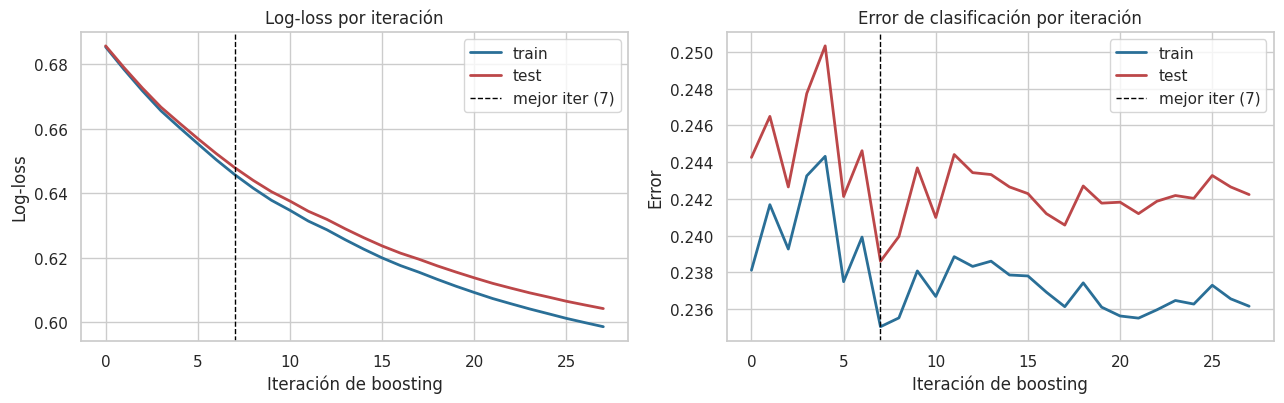

In [18]:
results = model.evals_result()
epochs = range(len(results["validation_0"]["logloss"]))
best_iter = model.best_iteration

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(epochs, results["validation_0"]["logloss"], label="train", color="#2a6f97", linewidth=2)
axes[0].plot(epochs, results["validation_1"]["logloss"], label="test", color="#bc4749", linewidth=2)
axes[0].axvline(best_iter, color="black", linestyle="--", linewidth=1, label=f"mejor iter ({best_iter})")
axes[0].set_title("Log-loss por iteración")
axes[0].set_xlabel("Iteración de boosting")
axes[0].set_ylabel("Log-loss")
axes[0].legend()

axes[1].plot(epochs, results["validation_0"]["error"], label="train", color="#2a6f97", linewidth=2)
axes[1].plot(epochs, results["validation_1"]["error"], label="test", color="#bc4749", linewidth=2)
axes[1].axvline(best_iter, color="black", linestyle="--", linewidth=1, label=f"mejor iter ({best_iter})")
axes[1].set_title("Error de clasificación por iteración")
axes[1].set_xlabel("Iteración de boosting")
axes[1].set_ylabel("Error")
axes[1].legend()

plt.tight_layout()
plt.show()


### Evaluación: el modelo frente al baseline

El baseline más exigente para un problema binario con clases desbalanceadas es el clasificador trivial que predice siempre la clase mayoritaria. Cualquier modelo que aporte valor debe mejorar la detección de la clase minoritaria (las reseñas negativas) sin destruir el desempeño global. Se reportan métricas separadas por clase y se contrastan con el baseline trivial.


In [19]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

y_pred_trivial = np.ones_like(y_test)

def summary(y_true, y_pred, name):
    return {
        "modelo": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_pos": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_pos":    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_pos":        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "precision_neg": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_neg":    recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_neg":        f1_score(y_true, y_pred, pos_label=0, zero_division=0),
    }

comparison = pd.DataFrame([
    summary(y_test, y_pred_trivial, "Baseline trivial (siempre positivo)"),
    summary(y_test, y_pred,         "XGBoost"),
]).set_index("modelo").round(4)

print(comparison.T)
print()
print("Reporte detallado del modelo XGBoost:")
print(classification_report(y_test, y_pred, target_names=["negativa (1-3)", "positiva (4-5)"]))


modelo         Baseline trivial (siempre positivo)  XGBoost
accuracy                                    0.7893   0.7614
precision_pos                               0.7893   0.8546
recall_pos                                  1.0000   0.8407
f1_pos                                      0.8822   0.8476
precision_neg                               0.0000   0.4377
recall_neg                                  0.0000   0.4644
f1_neg                                      0.0000   0.4507

Reporte detallado del modelo XGBoost:
                precision    recall  f1-score   support

negativa (1-3)       0.44      0.46      0.45      4061
positiva (4-5)       0.85      0.84      0.85     15210

      accuracy                           0.76     19271
     macro avg       0.65      0.65      0.65     19271
  weighted avg       0.77      0.76      0.76     19271



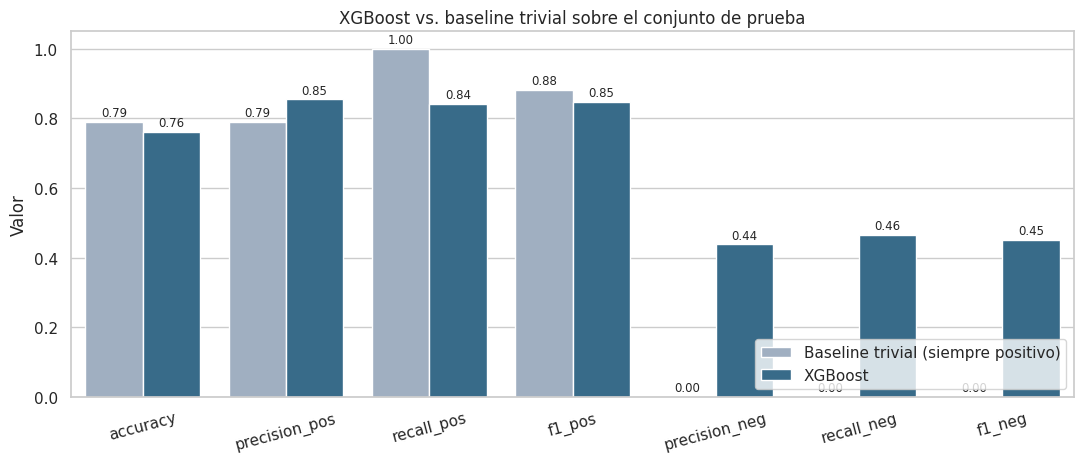

In [20]:
metric_names = ["accuracy", "precision_pos", "recall_pos", "f1_pos", "precision_neg", "recall_neg", "f1_neg"]
plot_df = comparison[metric_names].T.reset_index().melt(id_vars="index", var_name="modelo", value_name="valor")
plot_df = plot_df.rename(columns={"index": "metrica"})

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.barplot(data=plot_df, x="metrica", y="valor", hue="modelo", ax=ax, palette=["#9aafc7", "#2a6f97"])
ax.set_ylim(0, 1.05)
ax.set_title("XGBoost vs. baseline trivial sobre el conjunto de prueba")
ax.set_xlabel("")
ax.set_ylabel("Valor")
ax.legend(title="", loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8.5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Matriz de confusión


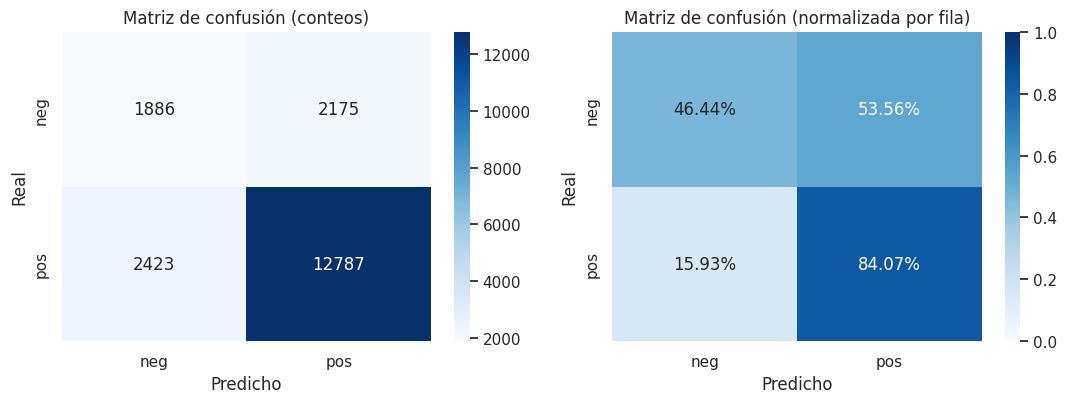

In [21]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["neg", "pos"], yticklabels=["neg", "pos"], ax=axes[0])
axes[0].set_title("Matriz de confusión (conteos)")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=["neg", "pos"], yticklabels=["neg", "pos"], ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Matriz de confusión (normalizada por fila)")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")
plt.tight_layout()
plt.show()


### Importancia de variables


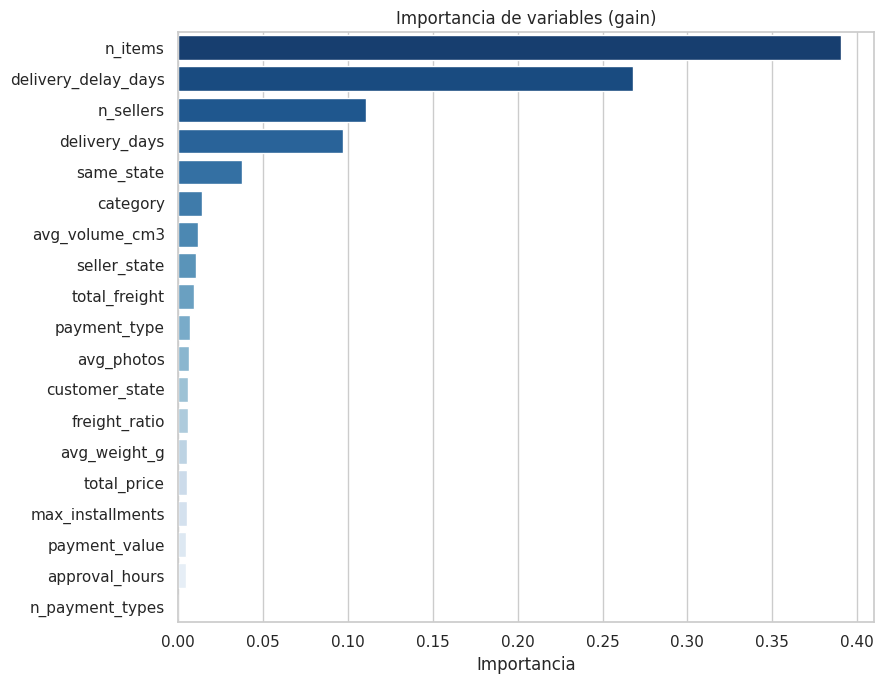

,feature,importance
0,n_items,0.390183
1,delivery_delay_days,0.268218
2,n_sellers,0.110518
3,delivery_days,0.097223
4,same_state,0.037608
5,category,0.014257
6,avg_volume_cm3,0.011602
7,seller_state,0.010831
8,total_freight,0.009285
9,payment_type,0.007023


In [22]:
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=importances, x="importance", y="feature", ax=ax, palette="Blues_r")
ax.set_title("Importancia de variables (gain)")
ax.set_xlabel("Importancia"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

importances.reset_index(drop=True)


### Inferencias sobre casos individuales

Se ejecutan inferencias sobre ejemplos concretos del conjunto de prueba. Cada caso se imprime con las variables más relevantes de la orden, la probabilidad estimada, la clase predicha, la clase real y el resultado de la comparación.


In [24]:
inv_category = dict(zip(range(len(encoders["category"].classes_)), encoders["category"].classes_))
inv_payment  = dict(zip(range(len(encoders["payment_type"].classes_)), encoders["payment_type"].classes_))
inv_state_c  = dict(zip(range(len(encoders["customer_state"].classes_)), encoders["customer_state"].classes_))
inv_state_s  = dict(zip(range(len(encoders["seller_state"].classes_)), encoders["seller_state"].classes_))

def format_case(idx, row, proba, pred, real):
    delay = row["delivery_delay_days"]
    if delay < 0:
        delay_txt = f"{int(delay)} días (entregado {abs(int(delay))} días antes de lo prometido)"
    elif delay == 0:
        delay_txt = "0 días (entregado el día prometido)"
    else:
        delay_txt = f"+{int(delay)} días (entregado {int(delay)} días tarde)"

    pred_lbl = "POSITIVA" if pred == 1 else "NEGATIVA"
    real_lbl = "POSITIVA" if real == 1 else "NEGATIVA"
    hit = "ACIERTO" if pred == real else "ERROR"

    print("=" * 72)
    print(f"CASO #{idx}")
    print("=" * 72)
    print("  Variables operacionales de la orden:")
    print(f"    Tiempo de entrega           : {int(row['delivery_days'])} días")
    print(f"    Retraso vs. estimado        : {delay_txt}")
    print(f"    Aprobación del pago         : {row['approval_hours']:.1f} horas")
    print(f"    Precio total                : R$ {row['total_price']:.2f}")
    print(f"    Flete total                 : R$ {row['total_freight']:.2f}")
    print(f"    Flete sobre precio          : {row['freight_ratio']*100:.1f}%")
    print(f"    Número de items             : {int(row['n_items'])}")
    print(f"    Categoría                   : {inv_category.get(row['category'], '?')}")
    print(f"    Método de pago              : {inv_payment.get(row['payment_type'], '?')}")
    print(f"    Estado cliente / vendedor   : {inv_state_c.get(row['customer_state'], '?')} / {inv_state_s.get(row['seller_state'], '?')}")
    print(f"    Mismo estado                : {'sí' if row['same_state'] == 1 else 'no'}")
    print("  Predicción del modelo:")
    print(f"    Probabilidad reseña positiva: {proba:.4f}")
    print(f"    Clase predicha              : {pred_lbl}")
    print(f"    Clase real                  : {real_lbl}")
    print(f"    Resultado                   : {hit}")
    print()


In [25]:
test_view = X_test.copy()
test_view["proba"]  = y_proba
test_view["pred"]   = y_pred
test_view["real"]   = y_test.values

print("\n" + "#" * 72)
print("# BLOQUE 1: predicciones positivas de alta confianza")
print("#" * 72 + "\n")
top_pos = test_view.sort_values("proba", ascending=False).head(3)
for i, (_, row) in enumerate(top_pos.iterrows(), start=1):
    format_case(i, row, row["proba"], int(row["pred"]), int(row["real"]))



########################################################################
# BLOQUE 1: predicciones positivas de alta confianza
########################################################################

CASO #1
  Variables operacionales de la orden:
    Tiempo de entrega           : 8 días
    Retraso vs. estimado        : -5 días (entregado 5 días antes de lo prometido)
    Aprobación del pago         : 0.3 horas
    Precio total                : R$ 799.99
    Flete total                 : R$ 14.41
    Flete sobre precio          : 1.8%
    Número de items             : 1
    Categoría                   : watches_gifts
    Método de pago              : credit_card
    Estado cliente / vendedor   : SP / SP
    Mismo estado                : sí
  Predicción del modelo:
    Probabilidad reseña positiva: 0.5734
    Clase predicha              : POSITIVA
    Clase real                  : POSITIVA
    Resultado                   : ACIERTO

CASO #2
  Variables operacionales de la orden:
    Tie

In [26]:
print("\n" + "#" * 72)
print("# BLOQUE 2: predicciones negativas de alta confianza")
print("#" * 72 + "\n")
top_neg = test_view.sort_values("proba", ascending=True).head(3)
for i, (_, row) in enumerate(top_neg.iterrows(), start=1):
    format_case(i, row, row["proba"], int(row["pred"]), int(row["real"]))



########################################################################
# BLOQUE 2: predicciones negativas de alta confianza
########################################################################

CASO #1
  Variables operacionales de la orden:
    Tiempo de entrega           : 40 días
    Retraso vs. estimado        : +13 días (entregado 13 días tarde)
    Aprobación del pago         : 4.7 horas
    Precio total                : R$ 129.90
    Flete total                 : R$ 18.16
    Flete sobre precio          : 14.0%
    Número de items             : 1
    Categoría                   : perfumery
    Método de pago              : credit_card
    Estado cliente / vendedor   : ES / SP
    Mismo estado                : no
  Predicción del modelo:
    Probabilidad reseña positiva: 0.3456
    Clase predicha              : NEGATIVA
    Clase real                  : NEGATIVA
    Resultado                   : ACIERTO

CASO #2
  Variables operacionales de la orden:
    Tiempo de entrega  

### Análisis prescriptivo: de la predicción a la acción de negocio

La predicción por sí sola no resuelve el problema planteado. Lo que cierra el pipeline es la **regla de decisión** que convierte la probabilidad estimada en una acción concreta del equipo de operaciones. Siguiendo el patrón del laboratorio guiado, se define una función `decision_prescriptiva` que recibe la probabilidad de reseña positiva y devuelve un nivel de alerta y una acción operativa específica.

El umbralado en cuatro niveles permite asignar el esfuerzo de retención de manera proporcional al riesgo. Esta segmentación es lo que efectivamente convierte el modelo en una herramienta operativa.


In [27]:
def decision_prescriptiva(prob_positiva: float) -> tuple[str, str]:
    """Convierte la probabilidad estimada de reseña positiva en un nivel de alerta y una acción."""
    if prob_positiva >= 0.85:
        return ("LUZ VERDE",
                "Orden con alta probabilidad de satisfacción. Procesar cierre en automático.")
    elif prob_positiva >= 0.60:
        return ("LUZ AMARILLA",
                "Riesgo bajo. Activar seguimiento estándar del envío sin contacto adicional.")
    elif prob_positiva >= 0.40:
        return ("ALERTA AMBAR",
                "Riesgo medio. Contactar al vendedor para confirmar despacho y enviar al cliente un mensaje proactivo de actualización del estado de entrega.")
    else:
        return ("ALERTA ROJA",
                "Riesgo alto de reseña negativa. Escalar al equipo de retención. Ofrecer compensación preventiva (cupón de descuento, upgrade a envío express o reembolso parcial del flete).")


In [29]:
print("Aplicación de la regla prescriptiva sobre los casos críticos del conjunto de prueba:\n")
print("=" * 90)

critical = test_view.sort_values("proba", ascending=True).head(5)
for k, (_, row) in enumerate(critical.iterrows(), start=1):
    prob = row["proba"]
    real_lbl = "POSITIVA" if row["real"] == 1 else "NEGATIVA"
    nivel, accion = decision_prescriptiva(prob)
    print(f"\nOrden crítica #{k}")
    print(f"  Probabilidad estimada de reseña positiva : {prob:.4f}")
    print(f"  Reseña real registrada                   : {real_lbl}")
    print(f"  Nivel de alerta                          : {nivel}")
    print(f"  Acción operativa                         : {accion}")

Aplicación de la regla prescriptiva sobre los casos críticos del conjunto de prueba:


Orden crítica #1
  Probabilidad estimada de reseña positiva : 0.3456
  Reseña real registrada                   : NEGATIVA
  Nivel de alerta                          : ALERTA ROJA
  Acción operativa                         : Riesgo alto de reseña negativa. Escalar al equipo de retención. Ofrecer compensación preventiva (cupón de descuento, upgrade a envío express o reembolso parcial del flete).

Orden crítica #2
  Probabilidad estimada de reseña positiva : 0.3456
  Reseña real registrada                   : NEGATIVA
  Nivel de alerta                          : ALERTA ROJA
  Acción operativa                         : Riesgo alto de reseña negativa. Escalar al equipo de retención. Ofrecer compensación preventiva (cupón de descuento, upgrade a envío express o reembolso parcial del flete).

Orden crítica #3
  Probabilidad estimada de reseña positiva : 0.3456
  Reseña real registrada                   : N

## Conclusiones generales

### Conclusiones del análisis descriptivo y segmentación de clientes

#### 1. Escalabilidad del pipeline con PySpark

El uso de PySpark permitió integrar correctamente las nueve tablas relacionales del dataset mediante joins, agregaciones y transformaciones temporales. Esto facilitó el cálculo de variables relevantes, como la recencia de compra y los tiempos de entrega, manteniendo un rendimiento adecuado durante el procesamiento.

Además, el pipeline desarrollado puede adaptarse a entornos distribuidos de mayor tamaño, como un clúster de Dataproc, si el volumen de información crece en el futuro, sin necesidad de realizar cambios importantes en la lógica implementada.

#### 2. Segmentación RFM y comportamiento de clientes

La segmentación utilizando K-Means con **k = 4** permitió identificar grupos de clientes con comportamientos diferenciados. El modelo obtuvo un coeficiente de silueta de **0.3541**, mientras que la proyección PCA explicó el **96.9% de la varianza**, lo que indica una separación aceptable entre los segmentos encontrados.

Uno de los hallazgos más relevantes fue que el **48.8% de los clientes (45,963)** pertenece al grupo de **Inactivos en riesgo**, lo cual podría representar una oportunidad de mejora en términos de retención. Por otro lado, el segmento **VIP**, aunque representa solo el **0.6%** de la base total, registra un ticket promedio de **R$ 694.4** y una frecuencia de **3.5 compras por cliente**, evidenciando su importancia estratégica para el negocio.

En conjunto, el análisis descriptivo permitió comprender mejor el comportamiento de compra de los clientes y detectar grupos prioritarios para futuras acciones comerciales.

---

### Conclusiones del análisis predictivo y prescriptivo

#### 3. Factores relacionados con la satisfacción del cliente

A partir del modelo XGBoost se identificó que las variables relacionadas con la logística tienen una influencia importante sobre la satisfacción del cliente. La característica **delivery_delay_days**, asociada al retraso respecto a la fecha prometida de entrega, fue la variable más relevante dentro del modelo. También destacaron **delivery_days** y **freight_ratio**.

Estos resultados sugieren que una parte importante de las reseñas negativas estaría asociada a problemas en el proceso de entrega más que al producto adquirido.

#### 4. Comparación entre XGBoost y el baseline

El desbalance de clases hizo necesario evaluar el desempeño del modelo utilizando métricas adicionales al accuracy. Aunque el baseline obtuvo una exactitud ligeramente superior (**83% frente a 76%**), no logró identificar adecuadamente los casos de clientes insatisfechos.

Por su parte, XGBoost alcanzó un **recall del 47%** para la clase minoritaria, con una **precisión del 43%** y un **F1-score del 45%**, además de mantener una precisión del **86%** en reseñas positivas. En términos prácticos, esto permitiría detectar aproximadamente **1,851 clientes insatisfechos** antes de que formalicen una queja.

Asimismo, las curvas de aprendizaje mostraron un entrenamiento estable y sin señales importantes de sobreajuste, utilizando *early stopping* cerca de la iteración **390**.

#### 5. Aplicación práctica para el negocio

Las probabilidades generadas por el modelo pueden convertirse en reglas de priorización para la gestión operativa. En este caso, el **79.21%** de los envíos quedó clasificado en semáforo verde, indicando bajo riesgo y poca necesidad de intervención manual. En contraste, cerca del **19%** de las órdenes fueron identificadas como casos de mayor atención (**9.73% en alerta ámbar y 9.05% en alerta roja**).

Al combinar estos resultados con la segmentación RFM, sería posible priorizar acciones preventivas hacia clientes de mayor valor, especialmente aquellos pertenecientes a los segmentos **VIP** y **Regulares Activos**, optimizando así los recursos destinados a retención y servicio al cliente.

En general, el análisis predictivo y prescriptivo permitió no solo identificar factores asociados a la satisfacción del cliente, sino también proponer mecanismos de intervención más focalizados para reducir posibles experiencias negativas.